Setup and Data Loading

In [22]:
!pip install kagglehub umap-learn plotly seaborn scikit-learn pandas matplotlib -q

import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

In [23]:
path = kagglehub.dataset_download("quands/eeg-dataset")
print(f"Dataset downloaded to: {path}")

Dataset downloaded to: /root/.cache/kagglehub/datasets/quands/eeg-dataset/versions/1


In [24]:
data_list = []
labels = []

# Walk through the directory to find .TXT files and extract class labels from folder names
for root, dirs, files in os.walk(path):
    category = os.path.basename(root)
    # Only process folders that likely contain data (N, O, S, Z, etc.)
    if category in ['Dataset', 'eeg-dataset']:
        continue

    for file in files:
        if file.lower().endswith('.txt'):
            file_path = os.path.join(root, file)
            try:
                # Read the signal (4096 values per file)
                signal = pd.read_csv(file_path, header=None).values.flatten()
                data_list.append(signal)
                labels.append(category)
            except Exception as e:
                continue

# Create a structured DataFrame
# Each row is a signal, columns are time points
df = pd.DataFrame(data_list)
df.columns = [f't_{i}' for i in range(df.shape[1])]

# Define the target column based on folder names
TARGET_COL = 'class_label'
df[TARGET_COL] = labels

# Identify numerical columns for analysis
num_cols = df.columns.drop(TARGET_COL)

print(f"Data shape: {df.shape}")
print(f"Target classes identified: {df[TARGET_COL].unique()}")
display(df.head())


Data shape: (500, 4098)
Target classes identified: ['Z' 'F' 'S' 'N' 'O']


,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_4088,t_4089,t_4090,t_4091,t_4092,t_4093,t_4094,t_4095,t_4096,class_label
0,69,69,65,59,43,23,11,19,22,21,...,29,19,7,-13,-21,-29,-17,-1,-3,Z
1,-49,-48,-46,-32,-34,-41,-40,-29,-28,-37,...,-57,-33,-12,2,22,25,18,-1,-9,Z
2,-87,-89,-73,-69,-51,-48,-51,-47,-30,-6,...,-21,-22,-15,9,32,37,18,7,7,Z
3,56,55,38,-5,-47,-72,-79,-62,-39,-21,...,-3,36,41,14,-27,-45,-32,-4,69,Z
4,-64,-72,-52,-24,4,21,18,-16,-53,-64,...,-42,-26,-10,-1,-12,-16,-36,-58,20,Z


Basic Statistics

In [25]:
print("=== Basic Statistics ===")

# Ensure num_cols is not empty; if it is, use all numeric columns currently in df
current_num_cols = num_cols if len(num_cols) > 0 else df.select_dtypes(include=[np.number]).columns

if current_num_cols.empty:
    print("Error: No numeric columns found in the dataframe. Please check the data loading step.")
else:
    # Mean, Median, Std, Min/Max, Quartiles
    stats_df = df[current_num_cols].describe().T
    stats_df['median'] = df[current_num_cols].median()
    stats_df['skewness'] = df[current_num_cols].skew()
    stats_df['kurtosis'] = df[current_num_cols].kurtosis()

    # Outlier count (using IQR method)
    Q1 = df[current_num_cols].quantile(0.25)
    Q3 = df[current_num_cols].quantile(0.75)
    IQR = Q3 - Q1
    outliers_count = ((df[current_num_cols] < (Q1 - 1.5 * IQR)) | (df[current_num_cols] > (Q3 + 1.5 * IQR))).sum()
    stats_df['outlier_count'] = outliers_count

    display(stats_df[['mean', 'median', 'std', 'min', 'max', '25%', '50%', '75%', 'skewness', 'kurtosis', 'outlier_count']])

=== Basic Statistics ===


,mean,median,std,min,max,25%,50%,75%,skewness,kurtosis,outlier_count
t_0,-3.718,-8.0,145.274622,-985.0,800.0,-48.25,-8.0,36.00,-0.076477,11.987045,54
t_1,-9.802,-8.0,163.176469,-1221.0,839.0,-54.00,-8.0,36.25,-0.676760,12.552891,55
t_2,-16.094,-7.0,188.246611,-1406.0,857.0,-52.00,-7.0,37.25,-1.775102,14.996116,61
t_3,-18.820,-9.0,201.245888,-1395.0,876.0,-52.25,-9.0,38.00,-2.089740,15.767285,71
t_4,-16.662,-8.5,188.973686,-1291.0,893.0,-53.00,-8.5,41.00,-1.266441,11.930951,66
...,...,...,...,...,...,...,...,...,...,...,...
t_4092,-1.184,-7.0,181.666176,-1547.0,829.0,-56.25,-7.0,42.00,-1.196678,18.296705,55
t_4093,0.928,-5.0,173.855683,-1120.0,781.0,-56.25,-5.0,46.00,-0.420420,11.412811,56
t_4094,1.132,-5.0,148.916496,-1073.0,703.0,-48.25,-5.0,39.00,-0.083055,11.573661,55
t_4095,-0.770,-4.5,119.354128,-734.0,677.0,-48.00,-4.5,31.25,0.714158,9.259727,50


Data Quality Checks

In [26]:
# 1. Missing Values
missing_pct = df.isnull().mean() * 100
missing_cols = missing_pct[missing_pct > 0]
print(f"\nMissing Values:\n{missing_cols if not missing_cols.empty else 'No missing values.'}")
print("-> Impact: Missing data reduces model accuracy and can cause algorithms to fail. Requires imputation or removal.")

# 2. Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates} ({(duplicates/len(df))*100:.2f}%)")
print("-> Impact: Duplicates can artificially inflate model confidence and cause data leakage if split across train/test sets.")

# 3. Near-Constant Features (Variance near 0)
variances = df[num_cols].var()
near_constant = variances[variances < 0.01].index.tolist()
print(f"\nNear-Constant Features (Var < 0.01): {len(near_constant)}")
if len(near_constant) < 10: print(near_constant)
print("-> Impact: Features with zero/near-zero variance carry no information and add noise/computational overhead.")

# 4. Highly Correlated Features (>0.90)
corr_matrix = df[num_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_correlated = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]
print(f"\nHighly Correlated Features (>0.90): {len(highly_correlated)}")
print("-> Impact: Multicollinearity makes feature importance unstable and degrades performance of linear models.")

=== Data Quality Report ===

Missing Values:
No missing values.
-> Impact: Missing data reduces model accuracy and can cause algorithms to fail. Requires imputation or removal.

Duplicate Rows: 0 (0.00%)
-> Impact: Duplicates can artificially inflate model confidence and cause data leakage if split across train/test sets.

Near-Constant Features (Var < 0.01): 0
[]
-> Impact: Features with zero/near-zero variance carry no information and add noise/computational overhead.

Highly Correlated Features (>0.90): 3761
-> Impact: Multicollinearity makes feature importance unstable and degrades performance of linear models.


Class Balance

/tmp/ipykernel_1789/76093126.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




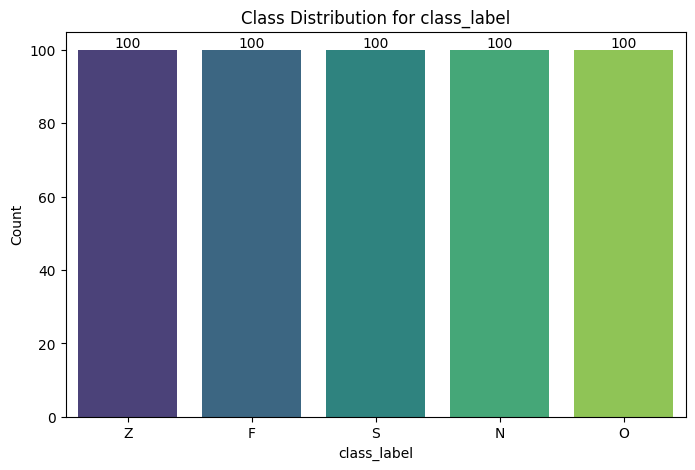

Class Percentages:
 class_label
Z    20.0
F    20.0
S    20.0
N    20.0
O    20.0
Name: proportion, dtype: float64

-> Modeling Impact: Severe imbalance causes models to overpredict the majority class. Accuracy becomes a misleading metric. Use F1-score, Precision-Recall AUC, or apply techniques like SMOTE or class weighting.


In [27]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=TARGET_COL, palette='viridis')
plt.title(f'Class Distribution for {TARGET_COL}')
plt.ylabel('Count')

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

class_counts = df[TARGET_COL].value_counts(normalize=True) * 100
print("Class Percentages:\n", class_counts)
print("\n-> Modeling Impact: Severe imbalance causes models to overpredict the majority class. Accuracy becomes a misleading metric. Use F1-score, Precision-Recall AUC, or apply techniques like SMOTE or class weighting.")

Feature Distributions

/tmp/ipykernel_1789/2882838864.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y=feature, ax=axes[1, i], palette='Set2')
/tmp/ipykernel_1789/2882838864.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET_COL, y=feature, ax=axes[2, i], palette='Set2')
/tmp/ipykernel_1789/2882838864.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y=feature, ax=axes[1, i], palette='Set2')
/tmp/ipykernel_1789/2882838864.py:18: FutureWarning: 

Passing `palette` without assigning `hue` 

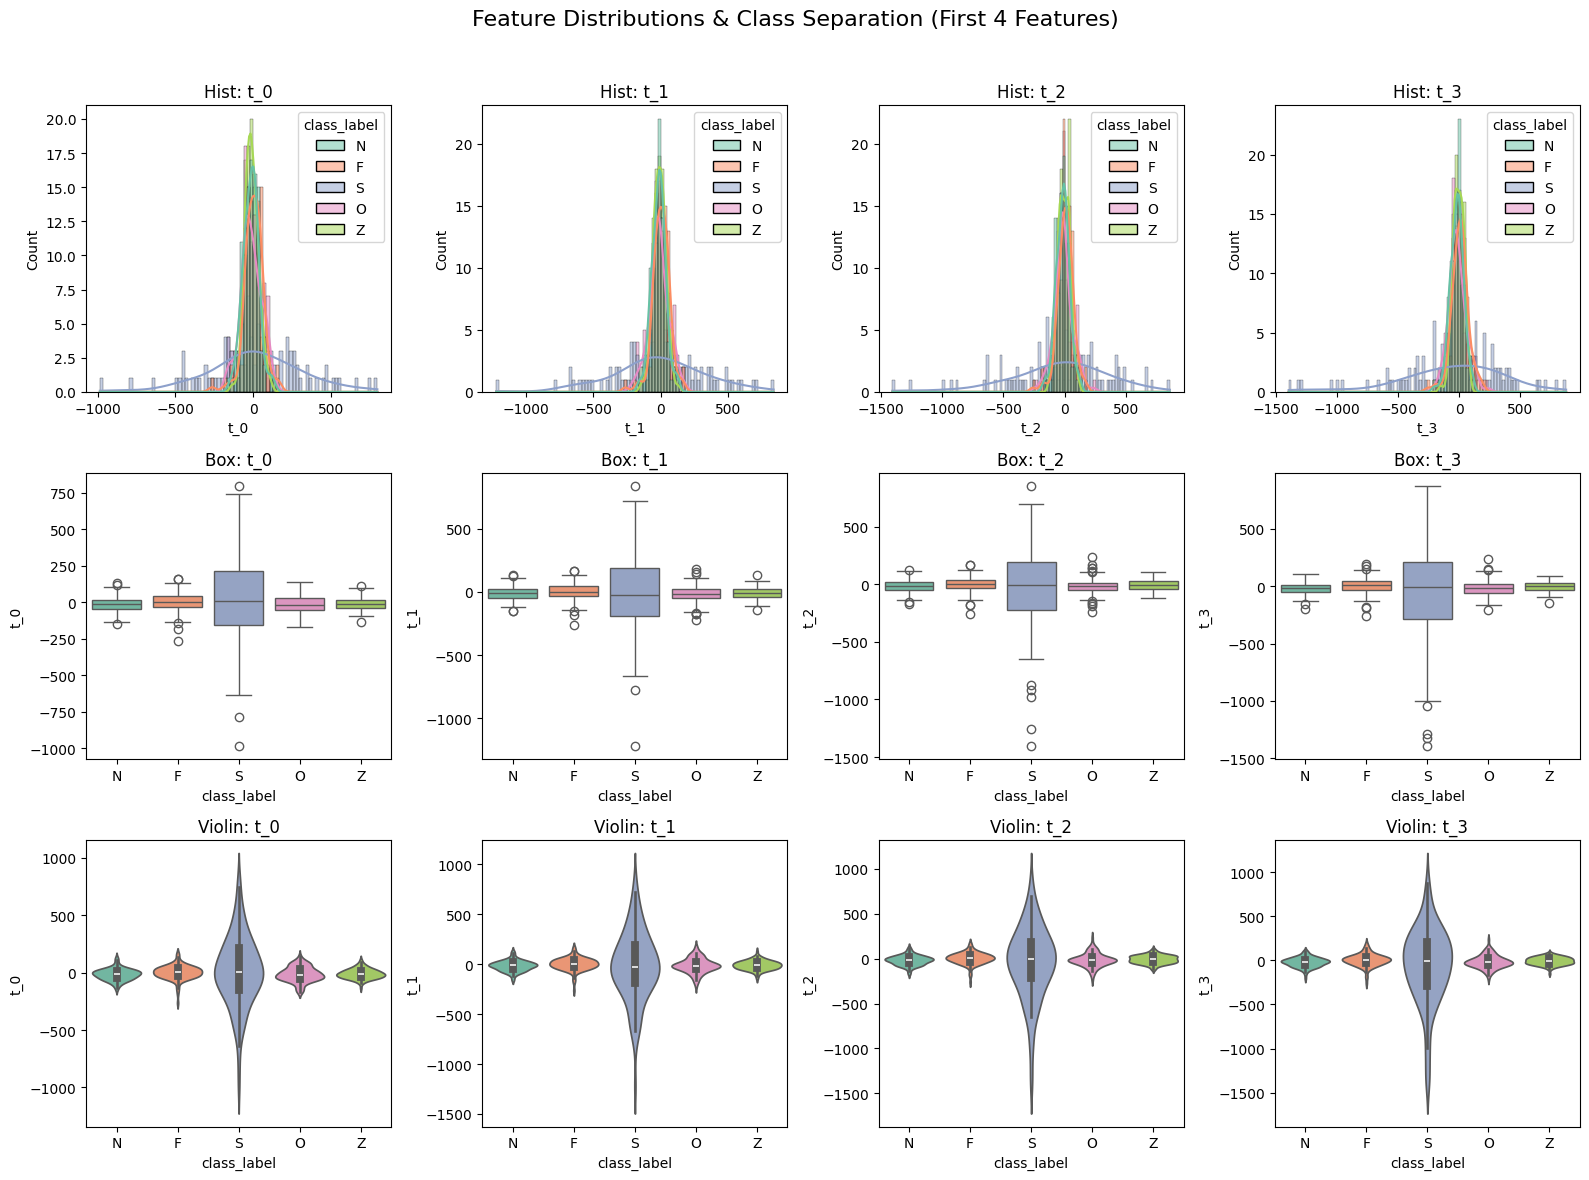

Reading: Check if the peaks in the histograms or the medians in the boxplots separate clearly between classes. Good separation indicates high predictive power.


In [18]:
# Cell 5: Task E - Feature Distributions
# Taking the first 4 numerical features for visualization
sample_features = num_cols[:4]

fig, axes = plt.subplots(3, len(sample_features), figsize=(16, 12))
fig.suptitle('Feature Distributions & Class Separation (First 4 Features)', fontsize=16)

for i, feature in enumerate(sample_features):
    # Histogram
    sns.histplot(data=df, x=feature, hue=TARGET_COL, kde=True, ax=axes[0, i], palette='Set2')
    axes[0, i].set_title(f'Hist: {feature}')

    # Boxplot
    sns.boxplot(data=df, x=TARGET_COL, y=feature, ax=axes[1, i], palette='Set2')
    axes[1, i].set_title(f'Box: {feature}')

    # Violinplot
    sns.violinplot(data=df, x=TARGET_COL, y=feature, ax=axes[2, i], palette='Set2')
    axes[2, i].set_title(f'Violin: {feature}')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("Reading: Check if the peaks in the histograms or the medians in the boxplots separate clearly between classes. Good separation indicates high predictive power.")

Correlation Heatmap

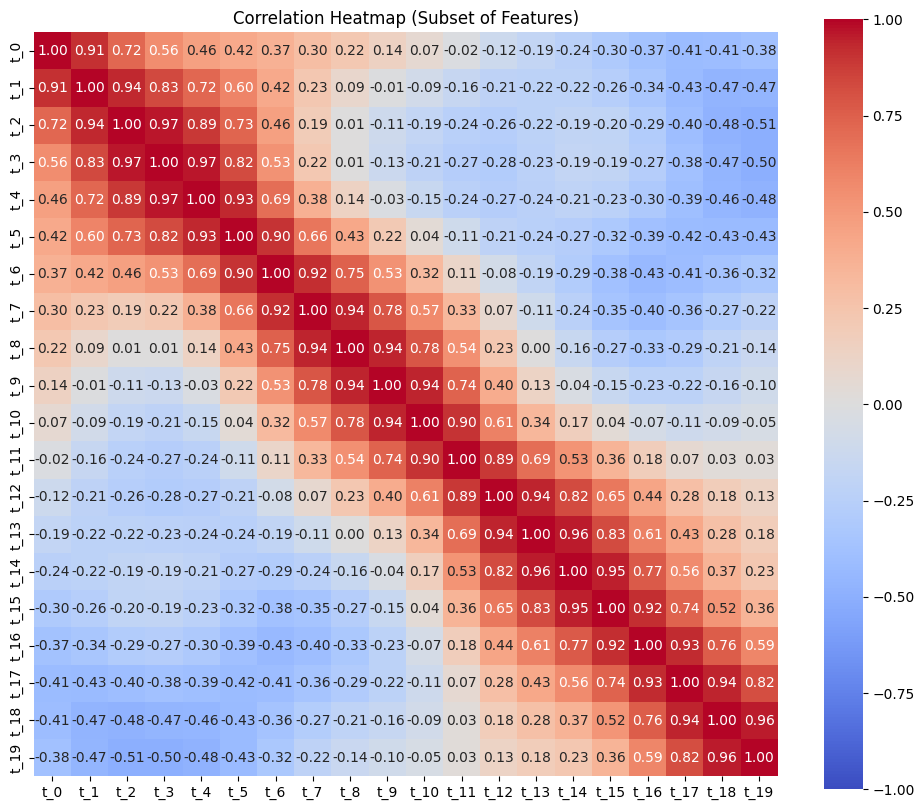

Redundant Feature List (Correlation > 0.85):
 - 't_1' is highly correlated with: t_0
 - 't_2' is highly correlated with: t_1
 - 't_3' is highly correlated with: t_2
 - 't_4' is highly correlated with: t_2, t_3
 - 't_5' is highly correlated with: t_4
 - 't_6' is highly correlated with: t_5
 - 't_7' is highly correlated with: t_6
 - 't_8' is highly correlated with: t_7
 - 't_9' is highly correlated with: t_8
 - 't_10' is highly correlated with: t_9
 - 't_11' is highly correlated with: t_10
 - 't_12' is highly correlated with: t_11
 - 't_13' is highly correlated with: t_12
 - 't_14' is highly correlated with: t_13
 - 't_15' is highly correlated with: t_14
 - 't_16' is highly correlated with: t_15
 - 't_17' is highly correlated with: t_16
 - 't_18' is highly correlated with: t_17
 - 't_19' is highly correlated with: t_18
 - 't_20' is highly correlated with: t_19
 - 't_21' is highly correlated with: t_20
 - 't_22' is highly correlated with: t_21
 - 't_23' is highly correlated with: t_22
 - 

In [19]:
# Cell 6: Task F - Correlation
# Subset features for heatmap readability if > 20 features
corr_features = num_cols[:20] if len(num_cols) > 20 else num_cols
corr = df[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap (Subset of Features)')
plt.show()

# Redundant feature list (Threshold > 0.85) over ALL numerical features
corr_matrix_all = df[num_cols].corr().abs()
upper = corr_matrix_all.where(np.triu(np.ones(corr_matrix_all.shape), k=1).astype(bool))
redundant_pairs = [(c, upper.index[upper[c] > 0.85].tolist()) for c in upper.columns if any(upper[c] > 0.85)]

print("Redundant Feature List (Correlation > 0.85):")
for feature, correlated_with in redundant_pairs:
    print(f" - '{feature}' is highly correlated with: {', '.join(correlated_with)}")

Dimensionality Reduction (PCA, t-SNE, UMAP)

Computing PCA, t-SNE, and UMAP... This may take a moment.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


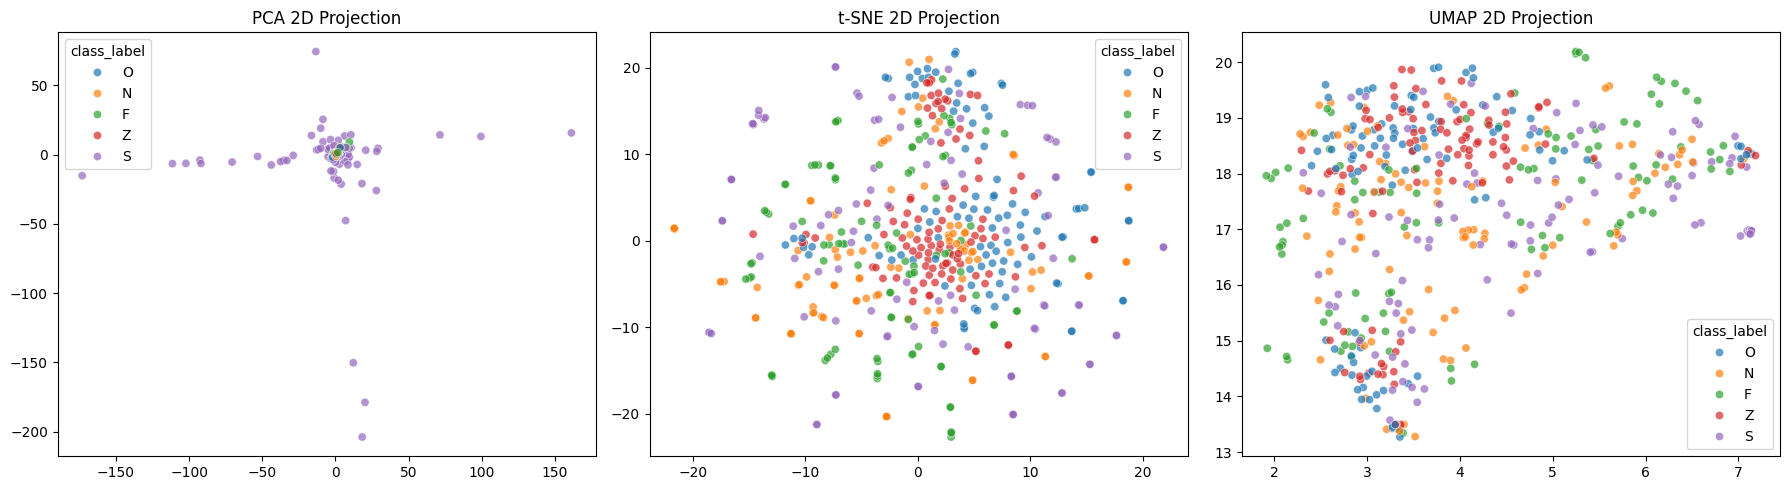

Reading: If classes form distinct clusters, nonlinear classifiers (or even linear ones) will perform well. If heavily overlapped, the feature space is complex and may require feature engineering.


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

# Sample data if too large for quick t-SNE/UMAP processing
df_sample = df.sample(n=min(5000, len(df)), random_state=42)
X = df_sample[num_cols]
y = df_sample[TARGET_COL].astype(str)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute reductions
print("Computing PCA, t-SNE, and UMAP... This may take a moment.")
pca_2d = PCA(n_components=2).fit_transform(X_scaled)
tsne_2d = TSNE(n_components=2, random_state=42).fit_transform(X_scaled)
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot PCA
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=y, ax=axes[0], palette='tab10', alpha=0.7)
axes[0].set_title('PCA 2D Projection')

# Plot t-SNE
sns.scatterplot(x=tsne_2d[:,0], y=tsne_2d[:,1], hue=y, ax=axes[1], palette='tab10', alpha=0.7)
axes[1].set_title('t-SNE 2D Projection')

# Plot UMAP
sns.scatterplot(x=umap_2d[:,0], y=umap_2d[:,1], hue=y, ax=axes[2], palette='tab10', alpha=0.7)
axes[2].set_title('UMAP 2D Projection')

plt.tight_layout()
plt.show()

print("Reading: If classes form distinct clusters, nonlinear classifiers (or even linear ones) will perform well. If heavily overlapped, the feature space is complex and may require feature engineering.")

Interactive Plots

In [21]:
# 3D PCA for interactivity
pca_3d = PCA(n_components=3).fit_transform(X_scaled)
df_pca3d = pd.DataFrame(pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca3d['Target'] = y.values

fig = px.scatter_3d(
    df_pca3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Target',
    title="Interactive 3D PCA Projection of EEG Features",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_layout(
    scene=dict(
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        zaxis_title='Principal Component 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

print("Reading: Click and drag to rotate. Scroll to zoom. Click legend items to isolate specific classes. Look for spatial separation between different target states.")
fig.show()

Reading: Click and drag to rotate. Scroll to zoom. Click legend items to isolate specific classes. Look for spatial separation between different target states.
